In [ ]:
import operator
from typing import Annotated, Dict, List, TypedDict


class QuestionStructureEval(TypedDict):
    score: int
    reasoning: str
    proposal: str


class AbbreviationEval(TypedDict):
    class AbbreviationExpansion(TypedDict):
        abbreviation: str
        expansion: List[str]

    abbreviations: AbbreviationExpansion


class DomainSpecificTermEval(TypedDict):
    domain_terms: List[str]
    proposal: str = "Replace with synonyms or longer explanations"


class KeywordEval(TypedDict):
    class KeywordExpansion(TypedDict):
        keyword: str
        expanded_keywords: List[str]  # Fuzz & Expand

    keywords: List[KeywordExpansion]


class OpenClosedEval(TypedDict):
    reasoning: str
    proposal: str


class EvaluationResult(TypedDict):
    question_structure: QuestionStructureEval
    abbreviation: AbbreviationEval
    domain_specific_term: DomainSpecificTermEval
    keyword: KeywordEval
    open_closed: OpenClosedEval


class RefinementResult(TypedDict):
    intention_score: int
    similarity_score: int
    refined_question: str


class State(TypedDict):
    class Refinement(TypedDict):
        evaluation_results: Annotated[EvaluationResult, operator.add]
        refined_question_results: List[RefinementResult]

    # original_question: Annotated[str, operator.add]
    original_question: str
    refinements: List[Refinement]

In [84]:
class EvaluationResultQuestion(TypedDict):
    question_structure: QuestionStructureEval
    abbreviations: AbbreviationEval
    domain_specific_term: DomainSpecificTermEval
    keyword: KeywordEval
    open_closed: OpenClosedEval
    question: str


class InitialState(TypedDict):
    question: str
    type_of_question: bool  # either refined or original question


class OverallState(TypedDict):
    original_question: str
    evaluation_results: EvaluationResult
    refinements: List[RefinementResult]


class RefinementQuestionInput(TypedDict):
    refined_question: str
    original_question: str

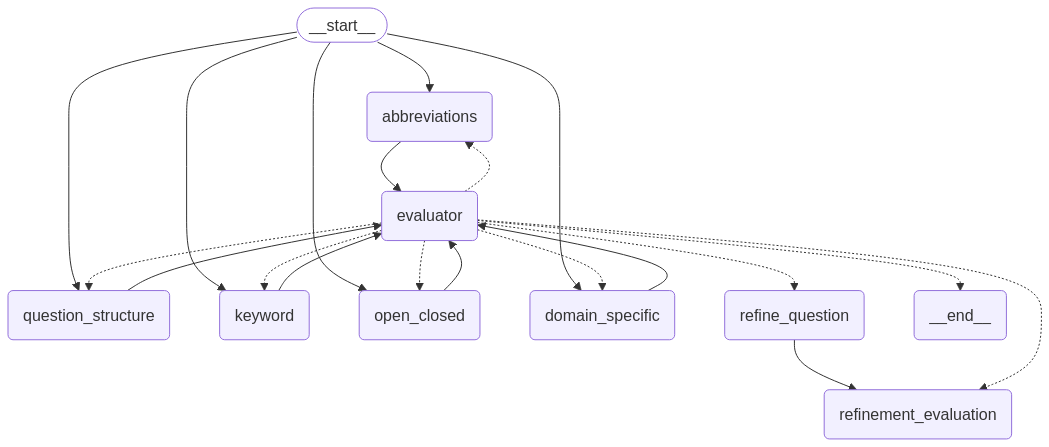

In [ ]:
from langgraph.types import Send, Command
from agents.state import QuestionStructureEval, State
from langgraph.graph import END, StateGraph, START
from datetime import datetime


def question_structure(state: InitialState) -> EvaluationResultQuestion:
    question_structure: QuestionStructureEval = {
        "proposal": "Updates on NewWater in Singapore",
        "reasoning": "Clarify logical flow",
        "score": 3,
    }
    print(f"Stage: question_structure, Time: {datetime.now()}")
    print(state)
    print("===================")

    return {"question_structure": question_structure}


def abbreviations(state: InitialState) -> EvaluationResultQuestion:
    abbreviation = {
        "abbreviation": "NWS",
        "expansion": ["New Water Service"],
    }
    abbreviations = [abbreviation]
    print(f"Stage: abbreviations, Time: {datetime.now()}")
    print(state)
    print("===================")
    return {"abbreviations": abbreviations}


def domain_specific(state: InitialState) -> EvaluationResultQuestion:
    domain_results = {
        "domain_terms": ["new water"],
        "proposal": "Replace with synonyms or longer explanations",
    }
    print(f"Stage: domain_specific, Time: {datetime.now()}")
    print(state)
    print("===================")
    return {"domain_specific_term": domain_results}


def keyword(state: InitialState) -> EvaluationResultQuestion:
    keyword_results = {
        "keyword": "new water",
        "expanded_keywords": ["new water", "xing shui"],
    }
    print(f"Stage: keyword, Time: {datetime.now()}")
    print(state)
    print("===================")
    return {"keyword": [keyword_results]}


def open_closed(state: InitialState) -> EvaluationResultQuestion:
    open_closed_results = {
        "proposal": "Be more specific and narrow",
        "reasoning": "Too broad, recall may be low",
    }
    # state["refinements"][-1]["evaluation_results"]["open_closed"] = open_closed_results
    print(f"Stage: open_closed, Time: {datetime.now()}")
    print(state)
    print("===================")
    return {"open_closed": open_closed_results}


def evaluator(state: EvaluationResultQuestion):
    print(f"Stage: evaluator, Time: {datetime.now()}")
    print(state)

    if True:
        return Send(
            "refine_question",
            {
                "original_question": state["question"],
                "evaluation_results": {
                    "question_structure": state["question_structure"],
                    "abbreviations": state["abbreviations"],
                    "domain_specific": state["domain_specific_term"],
                    "keyword": state["keyword"],
                    "open_closed": state["open_closed"],
                },
                "refinements": [],
            },
        )

    # TODO: If doesn't meet the score
    else:
        return END


def refine_question(state: OverallState) -> RefinementQuestionInput:
    _refined_question = "Provide updates on NewWater requirements in Singapore"
    print(f"Stage: refine_question, Time: {datetime.now()}")
    print(state)
    print("===================")
    return {
        "refined_question": _refined_question,
        "original_question": state["original_question"],
    }


def refinement_evaluation(state: RefinementQuestionInput) -> RefinementResult:
    refinement_question_results = {
        "intention_score": 9,
        "similarity_score": 0.85,
        "refined_question": state["refined_question"],
    }
    print(f"Stage: refinement_evaluation, Time: {datetime.now()}")
    print(state)
    print("===================")

    # IF score ok, then END
    if (
        refinement_question_results["intention_score"] >= 8
        and refinement_question_results["similarity_score"] <= 0.9
    ):
        return END
    # ELSE go back to refine question
    else:
        return Command(
            update=state,
            goto="refine_question",
        )


from langgraph.checkpoint.memory import MemorySaver

builder = StateGraph(InitialState)
builder.add_node("question_structure", question_structure)
builder.add_node("abbreviations", abbreviations)
builder.add_node("keyword", keyword)
builder.add_node("open_closed", open_closed)
builder.add_node("domain_specific", domain_specific)
builder.add_node("refine_question", refine_question)
builder.add_node("refinement_evaluation", refinement_evaluation)
builder.add_node("evaluator", evaluator)

builder.add_edge(START, "question_structure")
builder.add_edge(START, "abbreviations")
builder.add_edge(START, "keyword")
builder.add_edge(START, "open_closed")
builder.add_edge(START, "domain_specific")

builder.add_edge("question_structure", "evaluator")
builder.add_edge("abbreviations", "evaluator")
builder.add_edge("keyword", "evaluator")
builder.add_edge("open_closed", "evaluator")
builder.add_edge("domain_specific", "evaluator")
builder.add_conditional_edges("evaluator", evaluator)
builder.add_edge("refine_question", "refinement_evaluation")

memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [86]:
def initialize_state(original_question: str) -> InitialState:
    """Initializes the State with default values."""
    return {"question": original_question, "type_of_question": True}


state = initialize_state("What is the impact of LoRA on transformer efficiency?")

config = {"configurable": {"thread_id": "1"}}

results = []
for s in graph.stream(
    state,
    config,
):
    print(s)
    print("=====Next Stage====")
    results.append(s)


print("---------------")
print(results)

Stage: abbreviations, Time: 2025-03-16 22:40:20.309514
{'question': 'What is the impact of LoRA on transformer efficiency?', 'type_of_question': True}
Stage: question_structure, Time: 2025-03-16 22:40:20.310206
{'question': 'What is the impact of LoRA on transformer efficiency?', 'type_of_question': True}
Stage: keyword, Time: 2025-03-16 22:40:20.311485
{'question': 'What is the impact of LoRA on transformer efficiency?', 'type_of_question': True}
Stage: open_closed, Time: 2025-03-16 22:40:20.312458
{'question': 'What is the impact of LoRA on transformer efficiency?', 'type_of_question': True}
{'question_structure': [{'question_structure': {'proposal': 'Updates on NewWater in Singapore', 'reasoning': 'Clarify logical flow', 'score': 3}}, {'question_structure': 'question_structure'}]}
=====Next Stage====
{'abbreviations': [{'abbreviations': [{'abbreviation': 'NWS', 'expansion': ['New Water Service']}]}, {'abbreviations': 'abbreviations'}]}
=====Next Stage====
{'keyword': [{'keyword': [{

InvalidUpdateError: At key 'refined_question': Can receive only one value per step. Use an Annotated key to handle multiple values.
For troubleshooting, visit: https://python.langchain.com/docs/troubleshooting/errors/INVALID_CONCURRENT_GRAPH_UPDATE

In [ ]:
{
    "question_structure": "question_structure",
    "abbreviation": [{"abbreviation": "NWS", "expansion": ["New Water Service"]}],
    "domain_specific_term": {
        "domain_terms": ["new water"],
        "proposal": "Replace with synonyms or longer explanations",
    },
    "keyword": "keyword",
    "open_closed": "open_closed",
}

In [ ]:
# from langgraph.types import Command
# from agents.state import QuestionStructureEval, State
# from langgraph.graph import END, StateGraph, START
# from datetime import datetime


# def question_structure(state: State) -> EvaluationResult:
#     question_structure: QuestionStructureEval = {
#         "proposal": "Updates on NewWater in Singapore",
#         "reasoning": "Clarify logical flow",
#         "score": 3,
#     }
#     # state["refinements"][-1]["evaluation_results"][
#     #     "question_structure"
#     # ] = question_structure
#     print(f"Stage: question_structure, Time: {datetime.now()}")
#     print(state)
#     print("===================")

#     return question_structure


# def abbreviations(state: State) -> EvaluationResult:
#     abbreviation = {
#         "abbreviation": "NWS",
#         "expansion": ["New Water Service"],
#     }
#     abbreviations = [abbreviation]

#     # state["refinements"][-1]["evaluation_results"]["abbreviation"] = abbreviations

#     print(f"Stage: abbreviations, Time: {datetime.now()}")
#     print(state)
#     print("===================")
#     return abbreviation


# def domain_specific(state: State) -> DomainSpecificTermEval:
#     domain_results = {
#         "domain_terms": ["new water"],
#         "proposal": "Replace with synonyms or longer explanations",
#     }
#     # state["refinements"][-1]["evaluation_results"][
#     #     "domain_specific_term"
#     # ] = domain_results

#     print(f"Stage: domain_specific, Time: {datetime.now()}")
#     print(state)
#     print("===================")
#     return domain_results


# def keyword(state: State) -> KeywordEval:
#     keyword_results = {
#         "keyword": "new water",
#         "expanded_keywords": ["new water", "xing shui"],
#     }
#     # state["refinements"][-1]["evaluation_results"]["keyword"] = [keyword_results]

#     print(f"Stage: keyword, Time: {datetime.now()}")
#     print(state)
#     print("===================")
#     return {"keywords": [keyword_results]}


# def open_closed(state: State):
#     open_closed_results = {
#         "proposal": "Be more specific and narrow",
#         "reasoning": "Too broad, recall may be low",
#     }
#     # state["refinements"][-1]["evaluation_results"]["open_closed"] = open_closed_results
#     print(f"Stage: open_closed, Time: {datetime.now()}")
#     print(state)
#     print("===================")
#     return open_closed_results


# def refine_question(state: State):
#     _refined_question = "Provide updates on NewWater requirements in Singapore"
#     state["refinements"][-1]["refined_question_results"].append(
#         {"refined_question": _refined_question}
#     )
#     print(f"Stage: refine_question, Time: {datetime.now()}")
#     print(state)
#     print("===================")
#     return state


# def refinement_evaluation(state: State):
#     _refined_question = "Provide updates on NewWater requirements in Singapore"
#     state["refinements"][-1]["refined_question_results"][0] = {
#         "intention_score": 9,
#         "similarity_score": 0.85,
#         "refined_question": _refined_question,
#     }
#     print(f"Stage: refinement_evaluation, Time: {datetime.now()}")
#     print(state)
#     print("===================")
#     return state


# def evaluator(state: EvaluationResult) -> :
#     print(f"Stage: evaluator, Time: {datetime.now()}")
#     print(state)
#     current_refinement_results = state["refinements"][-1]

#     eval_results = current_refinement_results["evaluation_results"]

#     # Check if evaluation results require refining of questions
#     if eval_results["question_structure"]["score"] >= 5:

#         # Check if this question is the original question, if so no need to go through the "Refinement Evaluation" stage
#         ## Just need to check if refined_question_results have any values
#         if current_refinement_results["refined_question_results"]:
#             print("There are refinement questions")
#             return Command(
#                 update=state,
#                 goto="refinement_evaluate",
#             )
#         else:
#             print(
#                 "There are no refinement questions, the original question is good enough"
#             )
#             return END

#     else:
#         return Command(
#             update=state,
#             goto="refine_question",
#         )


# class RefinementResult(TypedDict):
#     intention_score: int
#     similarity_score: int
#     refined_question: str


# class State(TypedDict):

#     class Refinement(TypedDict):
#         evaluation_results: EvaluationResult
#         refined_question_results: List[RefinementResult]

#     # original_question: Annotated[str, operator.add]
#     original_question: str
#     refinements: List[Refinement]


# def refinement_evaluator(state: State):
#     print(f"Stage: Refinement Evaluator, Time: {datetime.now()}")
#     if state["refinements"][-1]:
#         print(
#             "Loop through refinements to see which refined question ok, or not okay and need to refine again"
#         )
#         return Command(
#             update=state,
#             goto="refine_question",  # NOTE: To take into consideration of feedback
#         )

#         # ELSE:
#         ## END if okay
#         # return END


# from langgraph.checkpoint.memory import MemorySaver

# builder = StateGraph(State)
# builder.add_node("question_structure", question_structure)
# builder.add_node("abbreviations", abbreviations)
# builder.add_node("keyword", keyword)
# builder.add_node("open_closed", open_closed)
# builder.add_node("domain_specific", domain_specific)
# builder.add_node("refine_question", refine_question)
# builder.add_node("refinement_evaluate", refinement_evaluation)
# builder.add_node("refinement_evaluator", refinement_evaluator)

# builder.add_node("evaluator", evaluator)

# builder.add_edge(START, "question_structure")
# builder.add_edge(START, "abbreviations")
# builder.add_edge(START, "keyword")
# builder.add_edge(START, "open_closed")
# builder.add_edge(START, "domain_specific")

# builder.add_edge("question_structure", "evaluator")
# builder.add_edge("abbreviations", "evaluator")
# builder.add_edge("keyword", "evaluator")
# builder.add_edge("open_closed", "evaluator")
# builder.add_conditional_edges("evaluator", evaluator)
# builder.add_edge("refinement_evaluate", "refinement_evaluator")

# memory = MemorySaver()
# graph = builder.compile(checkpointer=memory)

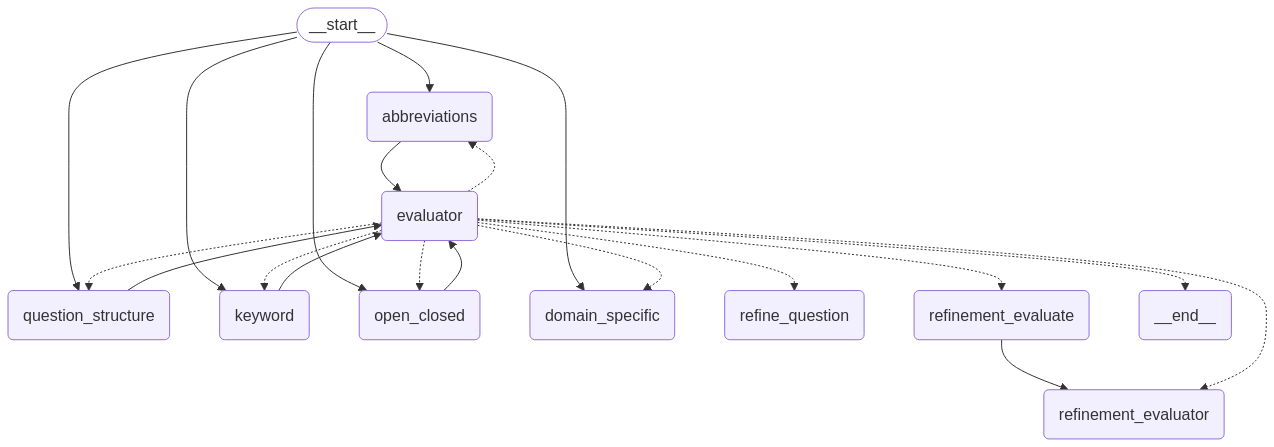

In [48]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [49]:
def initialize_state(original_question: str) -> State:
    """Initializes the State with default values."""
    return {
        "original_question": original_question,
        "refinements": [
            {
                "evaluation_results": {},
                "refined_question_results": [],
            }
        ],
    }


# Example usage:
state = initialize_state("What is the impact of LoRA on transformer efficiency?")

In [50]:
from langchain.globals import set_debug, set_verbose

set_debug(False)
config = {"configurable": {"thread_id": "1"}}

results = []
for s in graph.stream(
    state,
    config,
):
    print(s)
    print("=====Next Stage====")
    results.append(s)


print("---------------")
print(results)

Stage: keyword, Time: 2025-03-16 20:59:02.130629Stage: abbreviations, Time: 2025-03-16 20:59:02.133199
{'original_question': 'What is the impact of LoRA on transformer efficiency?', 'refinements': [{'evaluation_results': {}, 'refined_question_results': []}]}
Stage: open_closed, Time: 2025-03-16 20:59:02.134373
{'original_question': 'What is the impact of LoRA on transformer efficiency?', 'refinements': [{'evaluation_results': {}, 'refined_question_results': []}]}
Stage: question_structure, Time: 2025-03-16 20:59:02.134766
{'original_question': 'What is the impact of LoRA on transformer efficiency?', 'refinements': [{'evaluation_results': {}, 'refined_question_results': []}]}

{'original_question': 'What is the impact of LoRA on transformer efficiency?', 'refinements': [{'evaluation_results': {}, 'refined_question_results': []}]}
{'open_closed': None}
=====Next Stage====
{'abbreviations': None}
=====Next Stage====
{'keyword': None}
=====Next Stage====
Stage: domain_specific, Time: 2025-

KeyError: 'question_structure'